# Exercício 2, Item B: Pipeline Integrado de Percepção Visual

Notebook sequencial com as técnicas dos TPs e exercícios anteriores:
1. **Exercício 1:** captura de frame e correção de distorção (`cv2.undistort`);
2. **TP1:** segmentação de ROI por cor no espaço HSV (bola azul);
3. **TP2:** extração de features ORB (`cv2.ORB_create`);
4. **TP3:** detector de pedestres HOG+SVM (`cv2.HOGDescriptor`), a opção escolhida entre HOG+SVM e Haar Cascade;
5. **Exercício 2, Item A:** classificação da ROI com MobileNetV2 via OpenCV DNN.

O kernel deve rodar com o diretório de trabalho em `ex2/` (é assim que `main.py` o executa via `nbclient`).

In [1]:
import json
import time
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

RAIZ = Path.cwd()
ENTRADAS = RAIZ / 'entradas'
MODELOS = RAIZ / 'modelos'
SAIDAS = RAIZ / 'saidas'
FRAME_ALVO = 180
assert (ENTRADAS / 'bola.mp4').exists(), f'Execute o kernel dentro de ex2/ (cwd atual: {RAIZ})'
print('Módulos importados; diretório de trabalho:', RAIZ)

Módulos importados; diretório de trabalho: D:\AT_Visao_Computacional\ex2


## Etapa 1: captura de frame e correção de distorção (Exercício 1)

A calibração (`K` e coeficientes) vem da câmera virtual sintética do Exercício 1 e **não** corresponde à câmera que gravou `bola.mp4`: o passo é executado porque o enunciado exige encadeá-lo, mas sobre este vídeo ele não corrige distorção real.

In [2]:
calib = np.load(ENTRADAS / 'calibracao.npz')
K = calib['K']
dist = calib['dist']

cap = cv2.VideoCapture(str(ENTRADAS / 'bola.mp4'))
cap.set(cv2.CAP_PROP_POS_FRAMES, FRAME_ALVO)
ret, frame_bruto = cap.read()
cap.release()
if not ret:
    raise RuntimeError(f'Falha ao ler o frame {FRAME_ALVO} de bola.mp4')

t0 = time.perf_counter()
frame_undist = cv2.undistort(frame_bruto, K, dist, None, K)
t_etapa1 = (time.perf_counter() - t0) * 1000.0
print(f'Etapa 1: {t_etapa1:.2f} ms | frame {FRAME_ALVO} retificado ({frame_undist.shape[1]}x{frame_undist.shape[0]})')

Etapa 1: 10.79 ms | frame 180 retificado (1280x720)


## Etapa 2: segmentação de ROI por cor HSV (TP1)

In [3]:
t0 = time.perf_counter()
hsv = cv2.cvtColor(frame_undist, cv2.COLOR_BGR2HSV)
lower_blue = np.array([90, 60, 40], dtype=np.uint8)
upper_blue = np.array([130, 255, 255], dtype=np.uint8)
mask = cv2.inRange(hsv, lower_blue, upper_blue)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnts = [c for c in cnts if cv2.contourArea(c) >= 500]
if not cnts:
    raise RuntimeError('Nenhuma ROI azul encontrada neste frame; escolha outro FRAME_ALVO')
c_max = max(cnts, key=cv2.contourArea)
rx, ry, rw, rh = cv2.boundingRect(c_max)
roi = frame_undist[ry:ry+rh, rx:rx+rw]
t_etapa2 = (time.perf_counter() - t0) * 1000.0
print(f'Etapa 2: {t_etapa2:.2f} ms | ROI (x={rx}, y={ry}, w={rw}, h={rh})')

Etapa 2: 5.76 ms | ROI (x=425, y=247, w=261, h=258)


## Etapa 3: extração de features ORB (TP2)

In [4]:
t0 = time.perf_counter()
orb = cv2.ORB_create(nfeatures=2000, fastThreshold=5)
kp_roi, des_roi = orb.detectAndCompute(roi, None)
kp_global = [cv2.KeyPoint(kp.pt[0] + rx, kp.pt[1] + ry, kp.size, kp.angle, kp.response, kp.octave, kp.class_id) for kp in kp_roi]
t_etapa3 = (time.perf_counter() - t0) * 1000.0
print(f'Etapa 3: {t_etapa3:.2f} ms | {len(kp_global)} keypoints ORB na ROI')

Etapa 3: 207.89 ms | 62 keypoints ORB na ROI

## Etapa 4: detector de pedestres HOG+SVM (TP3)

`bola.mp4` não contém pessoas, portanto 0 detecções é o resultado esperado; a etapa é executada e cronometrada mesmo assim.

In [5]:
t0 = time.perf_counter()
hog = cv2.HOGDescriptor()
hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())
boxes_hog, _ = hog.detectMultiScale(frame_undist, winStride=(8, 8), padding=(8, 8), scale=1.05)
t_etapa4 = (time.perf_counter() - t0) * 1000.0
print(f'Etapa 4: {t_etapa4:.2f} ms | {len(boxes_hog)} pedestres detectados')

Etapa 4: 135.95 ms | 0 pedestres detectados


## Etapa 5: classificação da ROI com MobileNetV2 no OpenCV DNN (Item A)

ImageNet não tem a classe "bola azul"; o top-3 mostra as classes mais próximas que a rede conhece (por exemplo `soccer_ball`, `balloon`).

In [6]:
with open(MODELOS / 'imagenet_class_index.json', encoding='utf-8') as f:
    rotulos_id = {int(k): v[1] for k, v in json.load(f).items()}

net = cv2.dnn.readNetFromTFLite(str(MODELOS / 'mobilenetv2_imagenet.tflite'))
t0 = time.perf_counter()
blob = cv2.dnn.blobFromImage(roi, 1.0/127.5, (224, 224), (127.5, 127.5, 127.5), swapRB=True)
net.setInput(blob)
preds = net.forward()[0]
top3_idx = np.argsort(preds)[::-1][:3]
top3 = [(rotulos_id[int(i)], float(preds[i])) for i in top3_idx]
t_etapa5 = (time.perf_counter() - t0) * 1000.0
t_total = t_etapa1 + t_etapa2 + t_etapa3 + t_etapa4 + t_etapa5

for i, (nome, conf) in enumerate(top3, 1):
    print(f'  top-{i}: {nome} ({conf*100:.1f}%)')
print(f'Etapa 5: {t_etapa5:.2f} ms')
print(f'TEMPO TOTAL DO PIPELINE: {t_total:.2f} ms ({1000.0/t_total:.1f} FPS)')

  top-1: croquet_ball (20.1%)
  top-2: balloon (16.1%)
  top-3: vase (11.3%)
Etapa 5: 19.95 ms
TEMPO TOTAL DO PIPELINE: 380.32 ms (2.6 FPS)


## Frame final com as anotações de todas as etapas

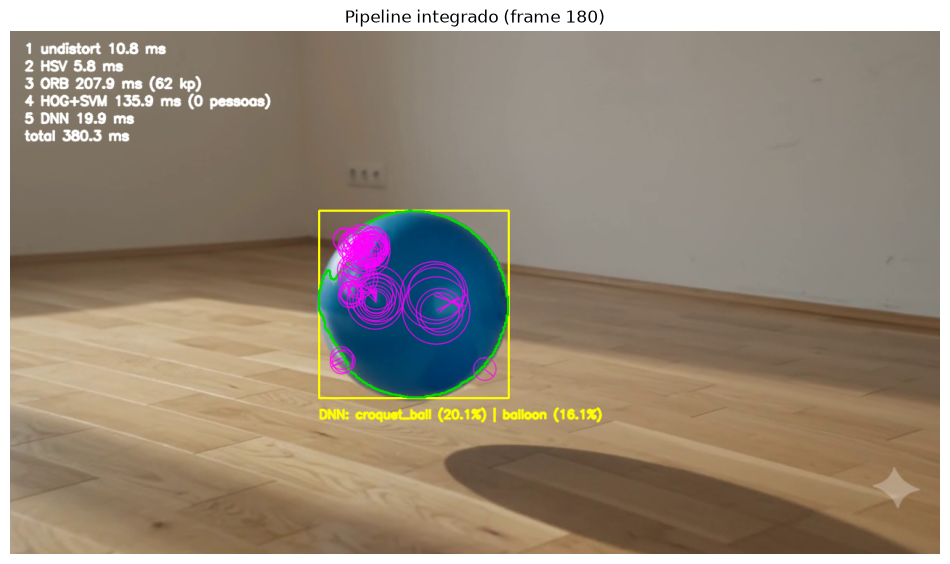

In [7]:
anotado = frame_undist.copy()
cv2.rectangle(anotado, (rx, ry), (rx + rw, ry + rh), (0, 255, 255), 2)
cv2.drawContours(anotado, [c_max], -1, (0, 220, 0), 2)
cv2.drawKeypoints(anotado, kp_global, anotado, color=(255, 0, 255), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
for bx, by, bw, bh in boxes_hog:
    cv2.rectangle(anotado, (bx, by), (bx + bw, by + bh), (0, 0, 255), 2)
texto = f'DNN: {top3[0][0]} ({top3[0][1]*100:.1f}%) | {top3[1][0]} ({top3[1][1]*100:.1f}%)'
cv2.putText(anotado, texto, (rx, min(ry + rh + 28, anotado.shape[0] - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 255, 255), 2, cv2.LINE_AA)
linhas = [f'1 undistort {t_etapa1:.1f} ms', f'2 HSV {t_etapa2:.1f} ms', f'3 ORB {t_etapa3:.1f} ms ({len(kp_global)} kp)',
          f'4 HOG+SVM {t_etapa4:.1f} ms ({len(boxes_hog)} pessoas)', f'5 DNN {t_etapa5:.1f} ms', f'total {t_total:.1f} ms']
for i, l in enumerate(linhas):
    cv2.putText(anotado, l, (20, 30 + 24 * i), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2, cv2.LINE_AA)

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(anotado, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f'Pipeline integrado (frame {FRAME_ALVO})')
plt.show()